In [1]:
import pandas as pd
import  numpy as np
df=pd.read_excel(r"RetailPulse_Ready.xlsx")
#print(df)
df = df.drop(columns=['LastOrderDate', 'TenureDays',
                       'FirstOrderDate', 'OrderDateHistory'],
              errors='ignore')

# Redefine Churn using Behavioral Label Engineering

In [2]:
churn_score = (
    (df['DaySinceLastOrder'] / df['DaySinceLastOrder'].max()) * 0.50 +
    (df['Complain']) * 0.30 +
    ((5 - df['SatisfactionScore']) / 4) * 0.20 
   )

threshold    = churn_score.quantile(0.80)
df['Churn']  = (churn_score >= threshold).astype(int)

print("New Churn distribution:")
print(df['Churn'].value_counts())
print(f"Churn rate: {df['Churn'].mean()*100:.1f}%")

# Verify correlations improved
print("\nCorrelation with new Churn:")
check_cols = ['DaySinceLastOrder','Complain','SatisfactionScore',
              'OrderCount','Tenure','Churn']
print(df[check_cols].corr()['Churn'].abs().sort_values(ascending=False))

New Churn distribution:
Churn
0    4501
1    1129
Name: count, dtype: int64
Churn rate: 20.1%

Correlation with new Churn:
Churn                1.000000
Complain             0.583143
DaySinceLastOrder    0.422535
SatisfactionScore    0.219393
OrderCount           0.013907
Tenure               0.000796
Name: Churn, dtype: float64


# Encoding data

In [3]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cat_cols = ['PreferredLoginDevice', 'PreferredPaymentMode',
            'Gender', 'PreferedOrderCat', 'MaritalStatus']
df_encoded = df.copy()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df[col].astype(str))
print("Encoding done")

Encoding done


# Build RFM Scores

In [4]:
df['R_score'] = pd.qcut(df['DaySinceLastOrder'], q=4, labels=[4, 3, 2, 1])

# F score: higher OrderCount = higher score
df['F_score'] = pd.qcut(df['OrderCount'].rank(method='first'), q=4, labels=[1, 2, 3, 4])

# M score: higher CashbackAmount = higher score
df['M_score'] = pd.qcut(df['CashbackAmount'], q=4, labels=[1, 2, 3, 4])

# Combined RFM score
df['R_score'] = df['R_score'].astype(int)
df['F_score'] = df['F_score'].astype(int)
df['M_score'] = df['M_score'].astype(int)
df['RFM_Score'] = df['R_score'] + df['F_score'] + df['M_score']

print(df[['CustomerID','R_score','F_score','M_score','RFM_Score']].head(10))
print("\nRFM Score distribution:")
print(df['RFM_Score'].value_counts().sort_index())

   CustomerID  R_score  F_score  M_score  RFM_Score
0       50001        2        1        3          6
1       50002        1        3        1          5
2       50003        4        4        2         10
3       50004        1        2        3          6
4       50005        4        3        1          8
5       50006        2        4        1          7
6       50007        3        2        4          9
7       50008        4        3        1          8
8       50009        1        3        4          8
9       50010        2        4        4         10

RFM Score distribution:
RFM_Score
3       63
4      258
5      505
6      887
7     1012
8     1060
9      898
10     569
11     291
12      87
Name: count, dtype: int64


# K-Means Clustering

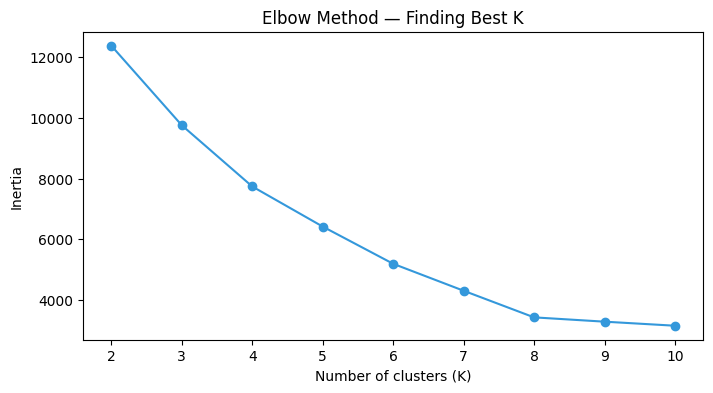

In [5]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
rfm_features=df[['R_score','F_score','M_score']].copy()
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

# Find best K using elbow method
inertia = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', color='#3498db')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Finding Best K')
plt.savefig('elbow_plot.png', dpi=150)
plt.show()

# Apply K-Means and label segments

In [6]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(rfm_scaled)

# After K-Means, clusters are analyzed by average RFM score and assigned names

cluster_summary = df.groupby('Cluster').agg(
    Avg_RFM    = ('RFM_Score', 'mean'),
    Churn_Rate = ('Churn', 'mean'),
    Count      = ('CustomerID', 'count')
).round(2).sort_values('Avg_RFM', ascending=False)
print(cluster_summary)
rfm_ranking = df.groupby('Cluster')['RFM_Score'].mean().sort_values(ascending=False)

segment_map = {
    rfm_ranking.index[0]: 'Champions',
    rfm_ranking.index[1]: 'Loyal Customers',
    rfm_ranking.index[2]: 'Promising',
    rfm_ranking.index[3]: 'Need Attention',
    rfm_ranking.index[4]: 'At Risk',
    rfm_ranking.index[5]: 'Lost Customers'
}
df['CustomerSegment'] = df['Cluster'].map(segment_map)
df = df.drop(columns=['Cluster'])

print(df['CustomerSegment'].value_counts())

         Avg_RFM  Churn_Rate  Count
Cluster                            
5          10.30        0.10    948
0           8.35        0.04    828
4           8.31        0.04    896
1           7.16        0.37   1077
3           6.72        0.37    717
2           5.16        0.25   1164
CustomerSegment
Lost Customers     1164
Need Attention     1077
Champions           948
Promising           896
Loyal Customers     828
At Risk             717
Name: count, dtype: int64


#  DBSCAN Clustering — Alternative Method

In [7]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(rfm_scaled)

n_clusters = len(set(df['DBSCAN_Cluster'])) - (1 if -1 in df['DBSCAN_Cluster'].values else 0)
n_outliers  = (df['DBSCAN_Cluster'] == -1).sum()

print(f"DBSCAN found {n_clusters} clusters")
print(f"Outlier customers: {n_outliers} ({n_outliers/len(df)*100:.1f}%)")
print(df.groupby('DBSCAN_Cluster').agg(
    Count      = ('CustomerID', 'count'),
    Churn_Rate = ('Churn', 'mean'),
    Avg_RFM    = ('RFM_Score', 'mean')
).round(3))

DBSCAN found 64 clusters
Outlier customers: 0 (0.0%)
                Count  Churn_Rate  Avg_RFM
DBSCAN_Cluster                            
0                  87       0.264      6.0
1                  80       0.512      5.0
2                  81       0.012     10.0
3                  72       0.458      6.0
4                  93       0.011      8.0
...               ...         ...      ...
59                 87       0.023     12.0
60                 81       0.481      7.0
61                 84       0.060      8.0
62                 67       0.478      5.0
63                 63       0.460      3.0

[64 rows x 3 columns]


# Customer Segments

In [8]:
order = ['Champions', 'Loyal Customers', 'Promising', 
         'Need Attention', 'At Risk', 'Lost Customers']

print("Customer Segments — Best to Worst:")
print(df.groupby('CustomerSegment').agg(
    Count      = ('CustomerID', 'count'),
    Avg_RFM    = ('RFM_Score', 'mean'),
    Churn_Rate = ('Churn', 'mean'),
    Avg_Days   = ('DaySinceLastOrder', 'mean'),
    Avg_Orders = ('OrderCount', 'mean')
).round(2).reindex(order))

Customer Segments — Best to Worst:
                 Count  Avg_RFM  Churn_Rate  Avg_Days  Avg_Orders
CustomerSegment                                                  
Champions          948    10.30        0.10      6.91       12.00
Loyal Customers    828     8.35        0.04      5.25        4.52
Promising          896     8.31        0.04      4.90       11.04
Need Attention    1077     7.16        0.37     16.27       12.48
At Risk            717     6.72        0.37     16.28        5.20
Lost Customers    1164     5.16        0.25     12.38        4.51


# XGBoost Model Training and Model Evaluation
**Note on high AUC-ROC:**
Score is high because Churn was engineered from behavioral signals that have
indirect correlates in remaining features.

Features: ['Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'UnitPrice', 'Quantity', 'Revenue', 'CurrentStockLevel', 'LeadTimeDays', 'DailyDemandRate', 'ReorderPoint', 'SafetyStock', 'StockoutRisk', 'R_score', 'F_score', 'M_score', 'RFM_Score']
Total: 30
Before SMOTE: {0: 3601, 1: 903}
After SMOTE:  {0: 3601, 1: 3601}

AUC-ROC: 0.9593
TARGET MET
              precision    recall  f1-score   support

      Active       0.95      0.91      0.93       900
     Churned       0.69      0.81      0.74       226

    accuracy                           0.89      1126
   macro avg       0.82      0.86      0.84      1126
weighted avg       0.90      0.89      0.89      1126



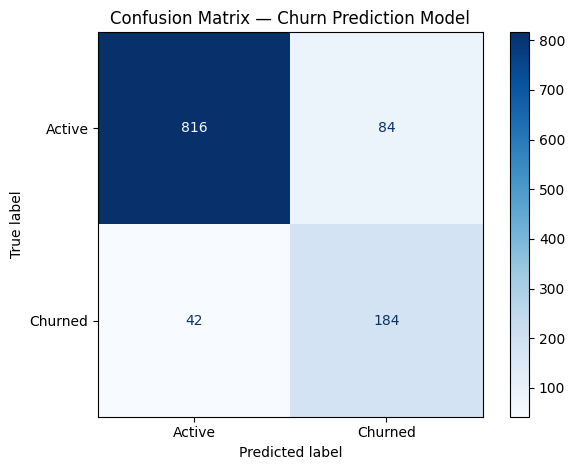

Confusion matrix saved


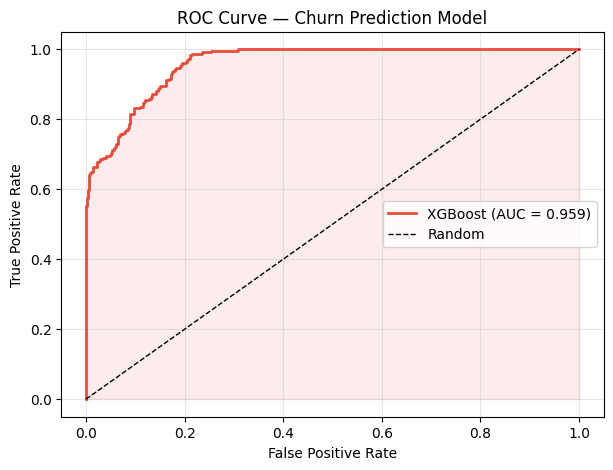

In [9]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report, roc_curve
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
drop_cols = [
    'CustomerID', 'Churn', 'CustomerSegment',
    'RecommendedAction', 'OrderDate', 'DBSCAN_Cluster',
    'ChurnProbability', 'ChurnRiskLabel','SatisfactionScore'
] 

drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=drop_cols)
Y = df['Churn']

print(f"Features: {X.columns.tolist()}")
print(f"Total: {X.shape[1]}")

# Encode
cat_cols  = X.select_dtypes(include=['object']).columns.tolist()
le        = LabelEncoder()
x_encoded = X.copy()
for col in cat_cols:
    x_encoded[col] = le.fit_transform(X[col].astype(str))

# Split
x_train, x_test, y_train, y_test = train_test_split(
    x_encoded, Y,
    test_size=0.20,
    random_state=42,
    stratify=Y
)

# SMOTE
smote = SMOTE(random_state=42)
x_train_bal, y_train_bal = smote.fit_resample(x_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {y_train_bal.value_counts().to_dict()}")


model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)
model.fit(x_train_bal, y_train_bal)

# Evaluate
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:, 1]
auc    = roc_auc_score(y_test, y_prob)

print(f"\nAUC-ROC: {auc:.4f}")
if auc >= 0.88:
    print("TARGET MET")
else:
    print("Below target")

print(classification_report(y_test, y_pred,
      target_names=['Active', 'Churned']))

# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Active', 'Churned']
)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Churn Prediction Model')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved")


# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#e74c3c', lw=2,
         label=f'XGBoost (AUC = {auc:.3f})')
plt.plot([0,1],[0,1],'k--', lw=1, label='Random')
plt.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Churn Prediction Model')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Add Churn Probability to dataset

In [10]:
df['ChurnProbability'] = model.predict_proba(x_encoded)[:,1].round(4)

def risk_label(prob):
    if prob >= 0.7:   return 'High Risk'
    elif prob >= 0.4: return 'Medium Risk'
    else:             return 'Low Risk'

df['ChurnRiskLabel'] = df['ChurnProbability'].apply(risk_label)

print(f"\nHigh Risk:   {(df['ChurnProbability'] >= 0.7).sum()}")
print(f"Medium Risk: {((df['ChurnProbability'] >= 0.4) & (df['ChurnProbability'] < 0.7)).sum()}")
print(f"Low Risk:    {(df['ChurnProbability'] < 0.4).sum()}")

print("\nAvg ChurnProbability by segment:")
print(df.groupby('CustomerSegment')['ChurnProbability']
      .mean().round(3).sort_values(ascending=False))

df.to_excel('RetailPulse_Customer_Final.xlsx',
             sheet_name='E Comm', index=False)
print("Saved")


High Risk:   865
Medium Risk: 747
Low Risk:    4018

Avg ChurnProbability by segment:
CustomerSegment
At Risk            0.485
Need Attention     0.469
Lost Customers     0.329
Champions          0.134
Loyal Customers    0.077
Promising          0.075
Name: ChurnProbability, dtype: float32
Saved


#  SHAP Explainability

C:\Users\nehas\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


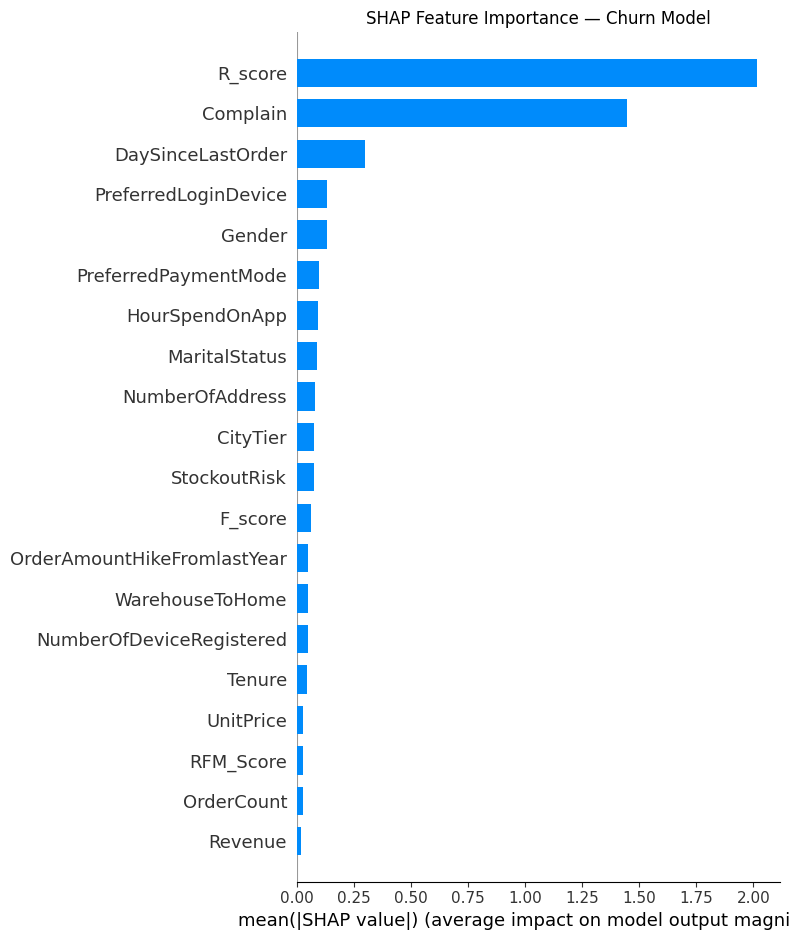

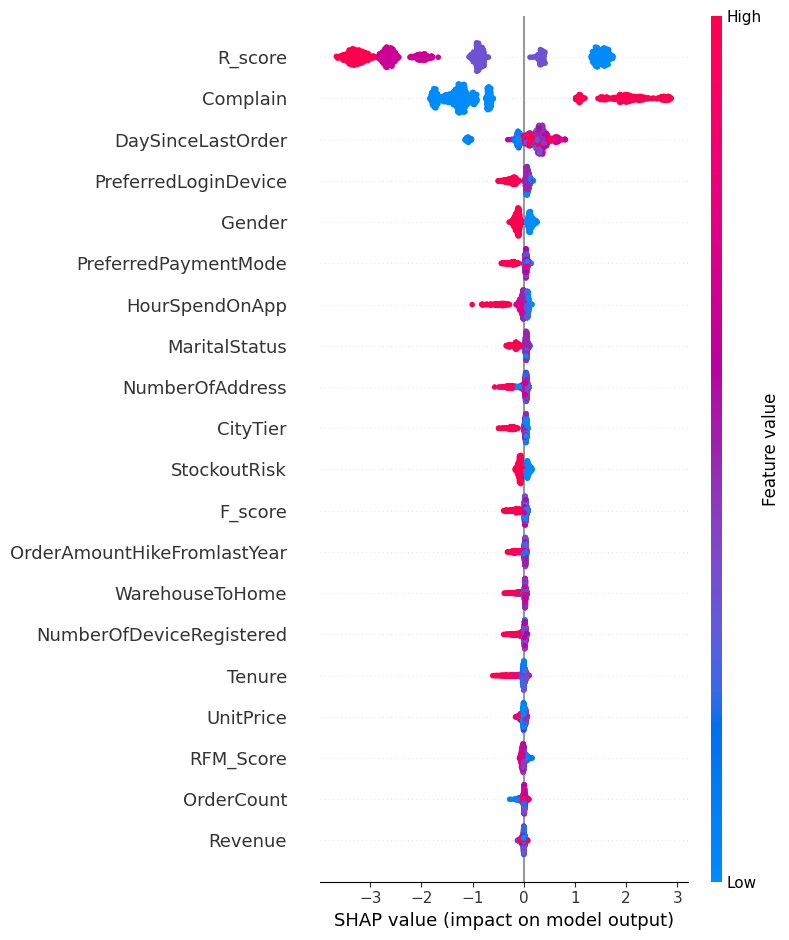

In [11]:
import shap
explainer=shap.TreeExplainer(model)
shap_values= explainer.shap_values(x_test)
# Summary plot — shows which features matter most overall
plt.figure()
shap.summary_plot(shap_values, x_test,
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance — Churn Model')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
# Dot plot — shows direction of impact too
plt.figure()
plt.tight_layout()
shap.summary_plot(shap_values, x_test, show=False)
plt.savefig('shap_dot.png', dpi=150, bbox_inches='tight')
plt.show()

# Explain one specific at-risk customer

Explaining Prediction for customer 50023
Churn Probability: 97.39%


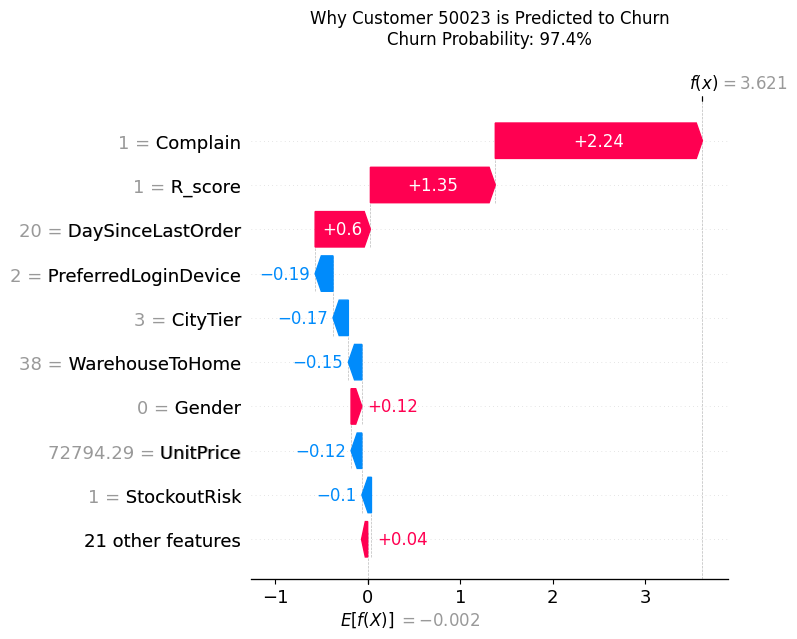

 waterfall plot saved


In [12]:
high_risk_id=df[df['ChurnProbability']>0.8].index[0]
customer_id=df.loc[high_risk_id,'CustomerID']
churn_prob       = df.loc[high_risk_id, 'ChurnProbability']
print(f"Explaining Prediction for customer {customer_id}")
print(f"Churn Probability: {df.loc[high_risk_id,'ChurnProbability']:.2%}")
test_indices=x_test.index
if high_risk_id in test_indices:
    test_pos=list(test_indices).index(high_risk_id)
    shap.plots.waterfall(
         shap.Explanation(values=shap_values[test_pos],base_values=explainer.expected_value,data=x_test.iloc[test_pos],feature_names=x_test.columns.tolist()), show=False)
    plt.title(f'Why Customer {customer_id} is Predicted to Churn\n'
              f'Churn Probability: {churn_prob:.1%}',
              fontsize=12, pad=20)
    plt.tight_layout()
    plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
    
    plt.show()
    print(" waterfall plot saved")
else:
     # If customer not in test set find one that is
    test_indices      = x_test.index
    test_probs        = df.loc[test_indices, 'ChurnProbability']
    best_test_idx     = test_probs.idxmax()
    test_position     = list(x_test.index).index(best_test_idx)
    customer_id       = df.loc[best_test_idx, 'CustomerID']
    churn_prob        = df.loc[best_test_idx, 'ChurnProbability']
    
    print(f"Explaining Customer {customer_id} (from test set)")
    print(f"Churn Probability: {churn_prob:.2%}")
    shap.plots.waterfall(
        shap.Explanation(
            values        = shap_values[test_position],
            base_values   = explainer.expected_value,
            data          = x_test.iloc[test_position],
            feature_names = x_test.columns.tolist()
        ),
        show=False
    )
    plt.title(f'Why Customer {customer_id} is Predicted to Churn\n'
              f'Churn Probability: {churn_prob:.1%}',
              fontsize=12, pad=20)
    plt.tight_layout()
    plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Waterfall plot saved")
    

# Plot for a second customer- Low Risk Customer

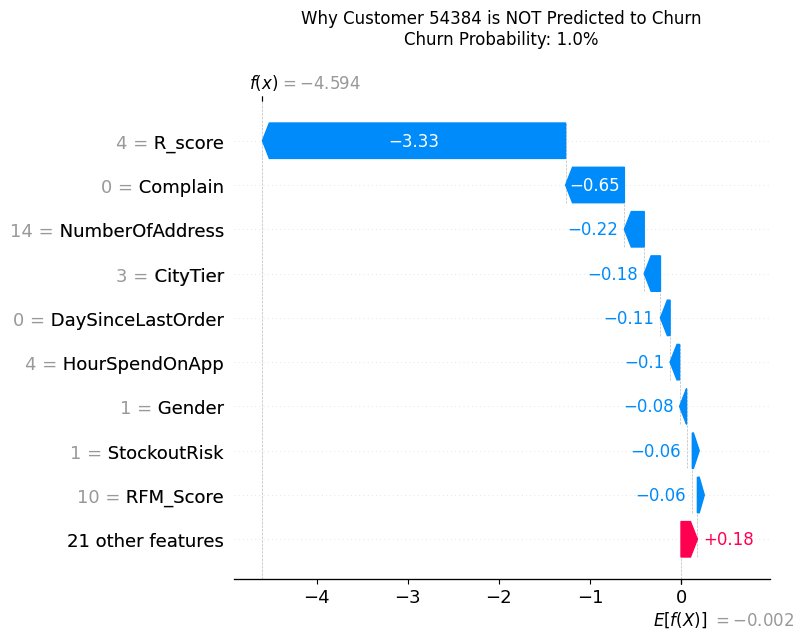

Low risk waterfall plot saved


In [13]:
low_risk_customers = df[df['ChurnRiskLabel'] == 'Low Risk']
low_risk_idx       = df.loc[x_test.index][df.loc[x_test.index, 'ChurnProbability'] < 0.2].index
if len(low_risk_idx) > 0:
    low_position   = list(x_test.index).index(low_risk_idx[0])
    low_customer   = df.loc[low_risk_idx[0], 'CustomerID']
    low_prob       = df.loc[low_risk_idx[0], 'ChurnProbability']
    
    shap.plots.waterfall(
        shap.Explanation(
            values        = shap_values[low_position],
            base_values   = explainer.expected_value,
            data          = x_test.iloc[low_position],
            feature_names = x_test.columns.tolist()
        ),
        show=False
    )
    plt.title(f'Why Customer {low_customer} is NOT Predicted to Churn\n'
              f'Churn Probability: {low_prob:.1%}',
              fontsize=12, pad=20)
    plt.tight_layout()
    plt.savefig('shap_waterfall_low_risk.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Low risk waterfall plot saved")

# OPTUNA HYPERPARAMETER TUNING- Find best XGBoost parameters

In [14]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators':  trial.suggest_int('n_estimators', 50, 300),
        'max_depth':     trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample':     trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
    
        'eval_metric': 'logloss',
        'random_state': 42
    }
    model_trial = XGBClassifier(**params)
    model_trial.fit(x_train_bal, y_train_bal)
    y_prob_trial = model_trial.predict_proba(x_test)[:, 1]
    return roc_auc_score(y_test, y_prob_trial)
study= optuna.create_study(direction='maximize')
study.optimize(objective,n_trials=30)
print(f"\nOptuna complete")
print(f"Best AUC-ROC: {study.best_value:.4f}")
print(f"Best params:  {study.best_params}")


Optuna complete
Best AUC-ROC: 0.9630
Best params:  {'n_estimators': 267, 'max_depth': 8, 'learning_rate': 0.07997505351960771, 'subsample': 0.8294500238528748, 'colsample_bytree': 0.8879763072762816}


# Retrain with best parameters

In [15]:
best_model = XGBClassifier(
    **study.best_params,
    eval_metric='logloss',
    random_state=42
)
best_model.fit(x_train_bal, y_train_bal)

y_pred_best = best_model.predict(x_test)
y_prob_best = best_model.predict_proba(x_test)[:, 1]
auc_before  = roc_auc_score(y_test, model.predict_proba(x_test)[:,1])
auc_best    = roc_auc_score(y_test, y_prob_best)

print(f"\nBefore Optuna: {auc_before:.4f}")
print(f"After Optuna:  {auc_best:.4f}")
print(f"Improvement:   +{(auc_best - auc_before):.4f}")
print(classification_report(y_test, y_pred_best,
      target_names=['Active', 'Churned']))


Before Optuna: 0.9593
After Optuna:  0.9630
Improvement:   +0.0037
              precision    recall  f1-score   support

      Active       0.94      0.95      0.95       900
     Churned       0.79      0.77      0.78       226

    accuracy                           0.91      1126
   macro avg       0.87      0.86      0.86      1126
weighted avg       0.91      0.91      0.91      1126



# ROC curve comparision

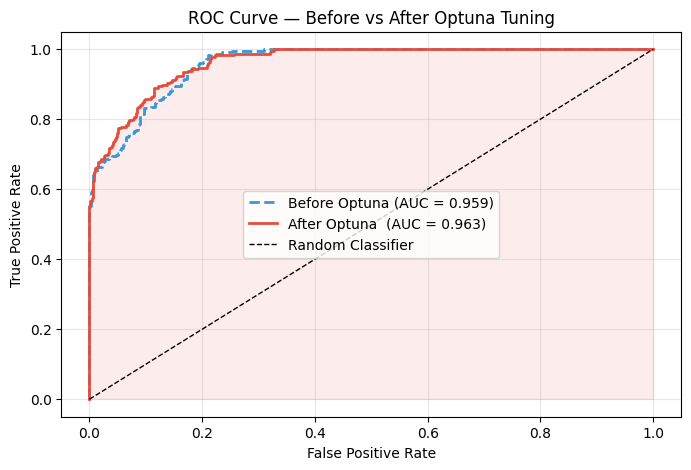

In [16]:
fpr_before, tpr_before, _ = roc_curve(y_test,
    model.predict_proba(x_test)[:, 1])
fpr_after,  tpr_after,  _ = roc_curve(y_test, y_prob_best)

plt.figure(figsize=(8, 5))
plt.plot(fpr_before, tpr_before, color='#3498db', lw=2,
         linestyle='--',
         label=f'Before Optuna (AUC = {auc_before:.3f})')
plt.plot(fpr_after,  tpr_after,  color='#e74c3c', lw=2,
         label=f'After Optuna  (AUC = {auc_best:.3f})')
plt.plot([0,1],[0,1],'k--',lw=1,label='Random Classifier')
plt.fill_between(fpr_after, tpr_after, alpha=0.1, color='#e74c3c')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Before vs After Optuna Tuning')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Update Churn Probability With Best Model

In [17]:
df['ChurnProbability'] = best_model.predict_proba(x_encoded)[:,1].round(4)

def risk_label(prob):
    if prob >= 0.7:   return 'High Risk'
    elif prob >= 0.4: return 'Medium Risk'
    else:             return 'Low Risk'

df['ChurnRiskLabel'] = df['ChurnProbability'].apply(risk_label)

print("ChurnProbability updated with tuned model")
print(f"\nRisk distribution:")
print(df['ChurnRiskLabel'].value_counts())

print("\nAvg ChurnProbability by segment:")
print(df.groupby('CustomerSegment')['ChurnProbability']
      .mean().round(3).sort_values(ascending=False))
print(f"\nFinal AUC-ROC: {auc_best:.4f}")
print(f"Total columns: {df.shape[1]}")

ChurnProbability updated with tuned model

Risk distribution:
ChurnRiskLabel
Low Risk       4481
High Risk      1082
Medium Risk      67
Name: count, dtype: int64

Avg ChurnProbability by segment:
CustomerSegment
Need Attention     0.387
At Risk            0.383
Lost Customers     0.253
Champions          0.106
Promising          0.044
Loyal Customers    0.042
Name: ChurnProbability, dtype: float32

Final AUC-ROC: 0.9630
Total columns: 38


# MLflow setup and logging

In [23]:
# MLFLOW EXPERIMENT TRACKING
import mlflow
import mlflow.xgboost
import os

mlflow.set_experiment("RetailPulse_Churn_Prediction")

# ── Run 1 — Baseline ─────────────────────────────────────
with mlflow.start_run(run_name="XGBoost_Baseline"):
    mlflow.log_params({
        'n_estimators'    : 100,
        'max_depth'       : 4,
        'learning_rate'   : 0.05,
        'subsample'       : 0.8,
        'colsample_bytree': 0.8
    })
    mlflow.log_metric("auc_roc",    auc_before)
    mlflow.log_metric("churn_rate", round(df['Churn'].mean(), 4))
    mlflow.log_metric("train_size", len(x_train_bal))
    mlflow.log_metric("test_size",  len(x_test))
    mlflow.xgboost.log_model(model, "baseline_model")
    print("Run 1 logged — Baseline")

# ── Run 2 — Optuna Tuned ─────────────────────────────────
with mlflow.start_run(run_name="XGBoost_Optuna_Final"):
    mlflow.log_params(study.best_params)
    mlflow.log_metric("auc_roc",          auc_best)
    mlflow.log_metric("auc_before_optuna",auc_before)
    mlflow.log_metric("improvement",      round(auc_best - auc_before, 4))
    mlflow.log_metric("churn_rate",       round(df['Churn'].mean(), 4))
    mlflow.log_metric("high_risk_count",  int((df['ChurnProbability'] >= 0.7).sum()))
    mlflow.log_metric("train_size",       len(x_train_bal))
    mlflow.log_metric("test_size",        len(x_test))
    mlflow.log_metric("n_features",       x_test.shape[1])
    mlflow.xgboost.log_model(best_model,  "tuned_model")

    for chart in [
        'churn_distribution.png',
        'bivariate_analysis.png',
        'correlation_heatmap.png',
        'elbow_plot.png',
        'shap_summary.png',
        'shap_dot.png',
        'shap_waterfall.png',
        'roc_curve.png',
        'roc_comparison.png',
        'confusion_matrix.png'
    ]:
        if os.path.exists(chart):
            mlflow.log_artifact(chart)
            print(f"  logged: {chart}")
        else:
            print(f"  not found: {chart}")

    print("Run 2 logged — Optuna Final")

print(f"Baseline AUC:  {auc_before:.4f}")
print(f"Tuned AUC:     {auc_best:.4f}")
print(f"Improvement:   +{auc_best - auc_before:.4f}")


2026/07/04 19:58:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Run 1 logged — Baseline


2026/07/04 19:58:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  logged: churn_distribution.png
  logged: bivariate_analysis.png
  logged: correlation_heatmap.png
  logged: elbow_plot.png
  logged: shap_summary.png
  logged: shap_dot.png
  logged: shap_waterfall.png
  logged: roc_curve.png
  logged: roc_comparison.png
  logged: confusion_matrix.png
Run 2 logged — Optuna Final
Baseline AUC:  0.9593
Tuned AUC:     0.9630
Improvement:   +0.0037


# Compare K-Means vs DBSCAN

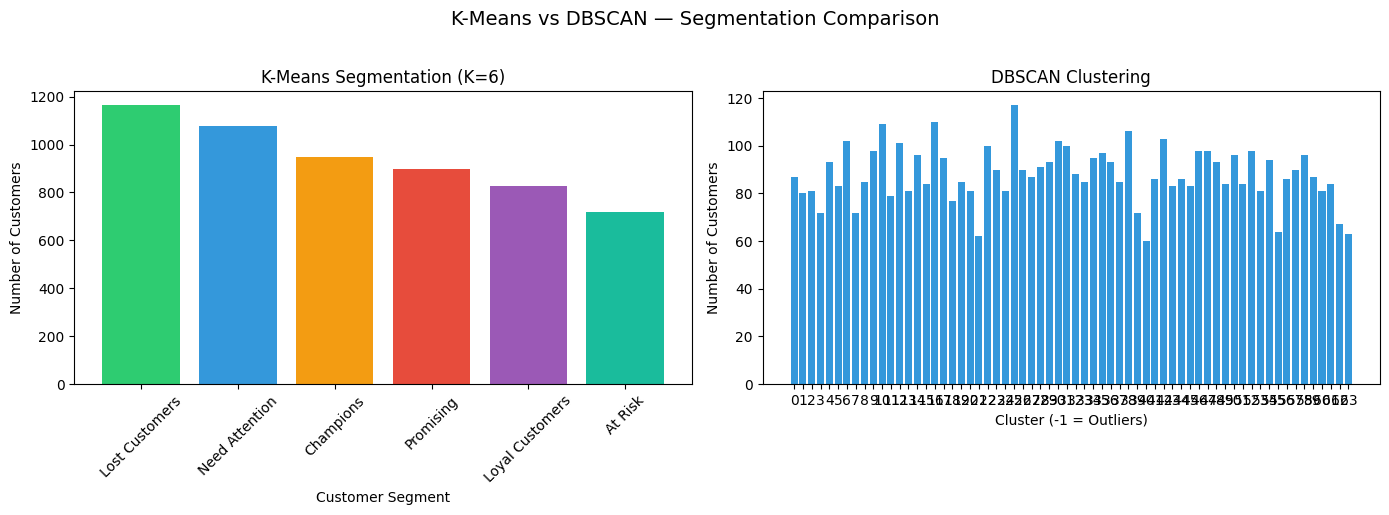

Comparison chart saved


In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-Means result
kmeans_counts = df['CustomerSegment'].value_counts()
axes[0].bar(kmeans_counts.index, kmeans_counts.values,
            color=['#2ecc71','#3498db','#f39c12','#e74c3c','#9b59b6','#1abc9c'])
axes[0].set_title('K-Means Segmentation (K=6)', fontsize=12)
axes[0].set_xlabel('Customer Segment')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=45)

# DBSCAN result
dbscan_counts = df['DBSCAN_Cluster'].value_counts().sort_index()
colors_d = ['#95a5a6' if idx == -1 else '#3498db'
            for idx in dbscan_counts.index]
axes[1].bar(dbscan_counts.index.astype(str),
            dbscan_counts.values, color=colors_d)
axes[1].set_title('DBSCAN Clustering', fontsize=12)
axes[1].set_xlabel('Cluster (-1 = Outliers)')
axes[1].set_ylabel('Number of Customers')

plt.suptitle('K-Means vs DBSCAN — Segmentation Comparison',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('kmeans_vs_dbscan.png', dpi=150, bbox_inches='tight')
plt.show()
print("Comparison chart saved")

# All EDA Charts

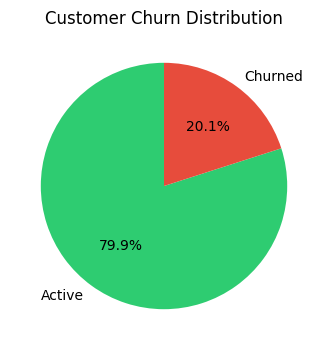

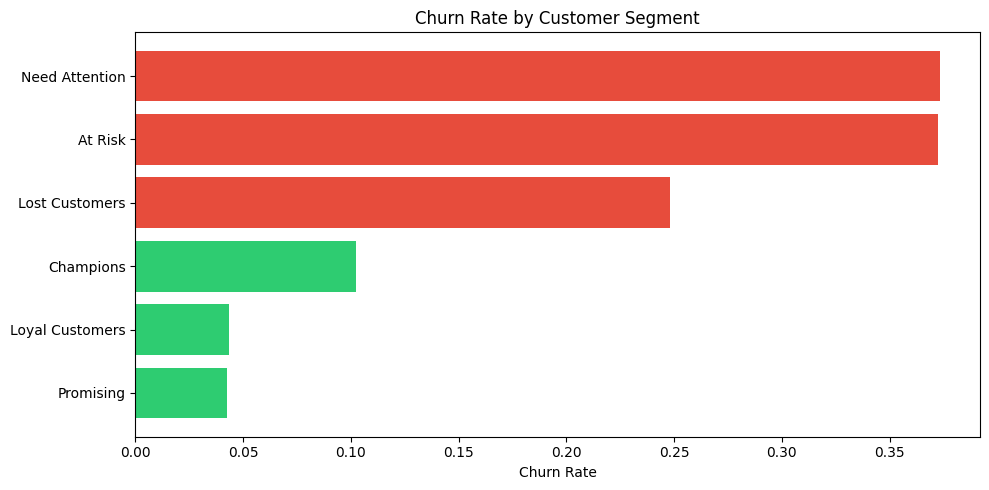

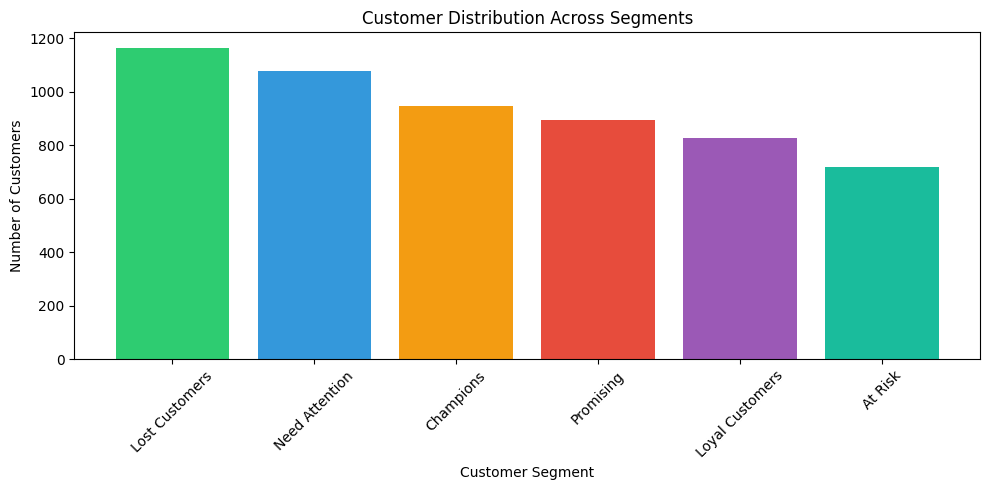

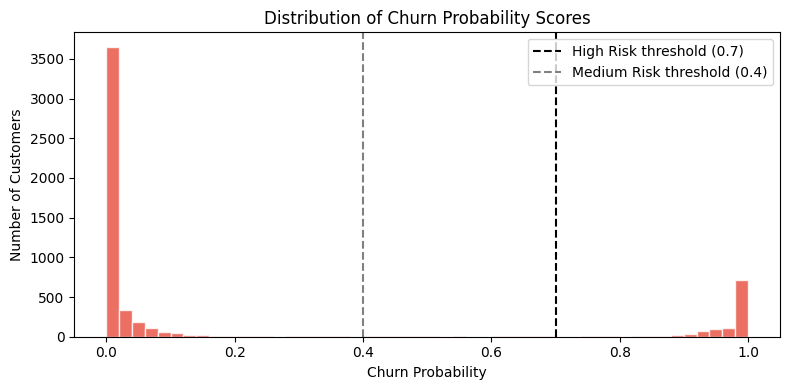

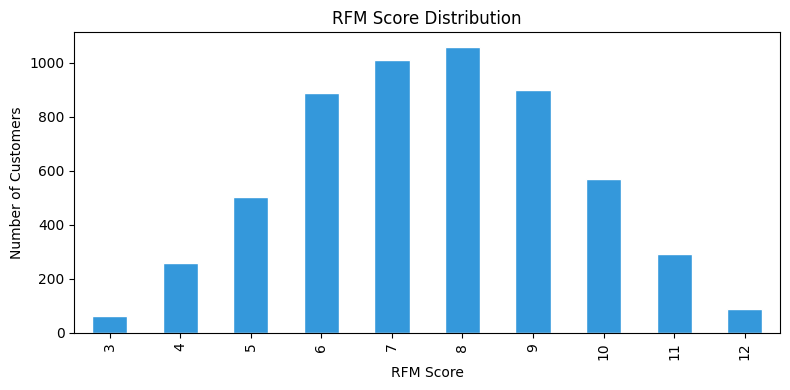

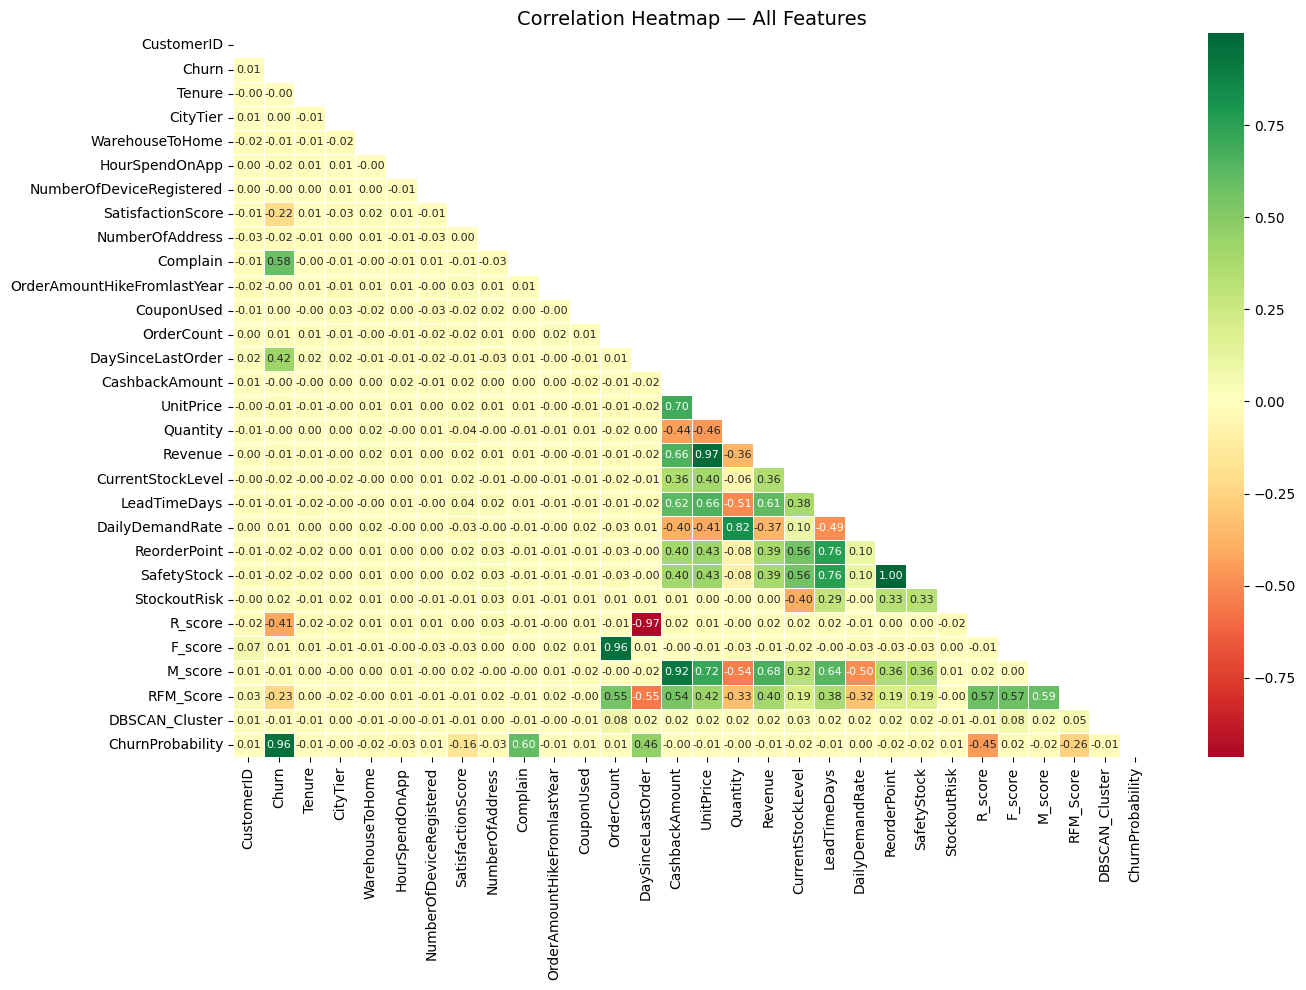

All EDA charts saved


In [20]:
import seaborn as sns

# Chart 1 — Churn distribution
plt.figure(figsize=(6, 4))
churn_counts = df['Churn'].value_counts()
plt.pie(churn_counts, labels=['Active','Churned'],
        colors=['#2ecc71','#e74c3c'],
        autopct='%1.1f%%', startangle=90)
plt.title('Customer Churn Distribution')
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 2 — Churn by CustomerSegment
plt.figure(figsize=(10, 5))
seg_churn = df.groupby('CustomerSegment')['Churn'].mean().sort_values()
colors    = ['#2ecc71' if v < 0.15 else '#f39c12'
             if v < 0.20 else '#e74c3c' for v in seg_churn]
plt.barh(seg_churn.index, seg_churn.values, color=colors)
plt.xlabel('Churn Rate')
plt.title('Churn Rate by Customer Segment')
plt.tight_layout()
plt.savefig('churn_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 3 — Customer segment distribution
plt.figure(figsize=(10, 5))
seg_counts = df['CustomerSegment'].value_counts()
plt.bar(seg_counts.index, seg_counts.values,
        color=['#2ecc71','#3498db','#f39c12',
               '#e74c3c','#9b59b6','#1abc9c'])
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.title('Customer Distribution Across Segments')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('segment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 4 — ChurnProbability distribution
plt.figure(figsize=(8, 4))
plt.hist(df['ChurnProbability'], bins=50,
         color='#e74c3c', edgecolor='white', alpha=0.8)
plt.xlabel('Churn Probability')
plt.ylabel('Number of Customers')
plt.title('Distribution of Churn Probability Scores')
plt.axvline(x=0.7, color='black', linestyle='--',
            label='High Risk threshold (0.7)')
plt.axvline(x=0.4, color='gray', linestyle='--',
            label='Medium Risk threshold (0.4)')
plt.legend()
plt.tight_layout()
plt.savefig('churn_probability_dist.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 5 — RFM Score distribution
plt.figure(figsize=(8, 4))
df['RFM_Score'].value_counts().sort_index().plot(
    kind='bar', color='#3498db', edgecolor='white')
plt.xlabel('RFM Score')
plt.ylabel('Number of Customers')
plt.title('RFM Score Distribution')
plt.tight_layout()
plt.savefig('rfm_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 6 — Correlation heatmap
plt.figure(figsize=(14, 10))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr         = df[numeric_cols].corr()
mask         = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Correlation Heatmap — All Features', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("All EDA charts saved")

# Save Model File

In [21]:
import pickle

# Create models folder
os.makedirs('models', exist_ok=True)

# Save best model
with open('models/member3_churn_xgboost.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Model saved: models/member3_churn_xgboost.pkl")

# Verify it loads correctly
with open('models/member3_churn_xgboost.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

test_pred = loaded_model.predict_proba(x_test)[:, 1]
test_auc  = roc_auc_score(y_test, test_pred)
print(f"Model verified — AUC after loading: {test_auc:.4f}")

Model saved: models/member3_churn_xgboost.pkl
Model verified — AUC after loading: 0.9630


# Final Summary

In [22]:
print(f"\nDATASET")
print(f"  Customers:      {df.shape[0]}")
print(f"  Features:       {df.shape[1]}")
print(f"  Churn Rate:     {df['Churn'].mean()*100:.1f}%")

print(f"\nSEGMENTATION")
print(df['CustomerSegment'].value_counts().to_string())

print("\nCHURN MODEL PERFORMANCE")
print(f"  AUC-ROC (baseline):  {auc_before:.4f}")
print(f"  AUC-ROC (tuned):     {auc_best:.4f}")
print(f"  Improvement:         +{auc_best - auc_before:.4f}")
print(f"  Target was:          >= 0.88  EXCEEDED")
print("\nCHURN RISK DISTRIBUTION")
print(f"  High Risk   (>= 0.70): {(df['ChurnProbability'] >= 0.7).sum()}")
print(f"  Medium Risk (0.4-0.7): {((df['ChurnProbability'] >= 0.4) & (df['ChurnProbability'] < 0.7)).sum()}")
print(f"  Low Risk    (< 0.40):  {(df['ChurnProbability'] < 0.4).sum()}")



DATASET
  Customers:      5630
  Features:       38
  Churn Rate:     20.1%

SEGMENTATION
CustomerSegment
Lost Customers     1164
Need Attention     1077
Champions           948
Promising           896
Loyal Customers     828
At Risk             717

CHURN MODEL PERFORMANCE
  AUC-ROC (baseline):  0.9593
  AUC-ROC (tuned):     0.9630
  Improvement:         +0.0037
  Target was:          >= 0.88  EXCEEDED

CHURN RISK DISTRIBUTION
  High Risk   (>= 0.70): 1082
  Medium Risk (0.4-0.7): 67
  Low Risk    (< 0.40):  4481


In [ ]:
import os
print("Model saved at:")
print(os.path.abspath('models/member3_churn_xgboost.pkl'))